<a href="https://colab.research.google.com/github/benram2004-lab/mis433/blob/main/Assignment_IMDB_visualization_Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/imdb_top_1000.csv', header=0)
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [4]:
# List all the column names:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Part 1: Data Manipulation

Redo the following to clean the data.

In [5]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()
imdb['Released_Year'].value_counts()

,count
Released_Year,
2014,32
2004,31
2009,29
2013,28
2016,28
...,...
1920,1
1930,1
1922,1


In [6]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.
(imdb.loc[~imdb['Released_Year'].str.isnumeric()])

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [7]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value
imdb.loc[966, 'Released_Year'] = '1995'
imdb.loc[966, 'Certificate'] = 'PG'
(imdb.loc[966, ['Series_Title', 'Released_Year', 'Certificate']])

,966
Series_Title,Apollo 13
Released_Year,1995
Certificate,PG


In [8]:
# Change the data type of "Released_Year" to int
imdb.loc[:, 'Released_Year'] = imdb['Released_Year'].astype(int)

In [9]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
(imdb.loc[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5),
           ['Series_Title', 'Released_Year', 'Certificate', 'Gross']]) \
    .sort_values(by='Gross', ascending=False)

,Series_Title,Released_Year,Certificate,Gross
19,Gisaengchung,2019,A,"53,367,844"
33,Joker,2019,A,"335,451,311"
8,Inception,2010,UA,"292,576,195"
21,Interstellar,2014,UA,"188,020,017"
35,The Intouchables,2011,UA,"13,182,281"
34,Whiplash,2014,A,"13,092,000"
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [10]:
# Does the sorting result looks right to you? What's the problem?
# Answer: The formatting looks right, not sure if decimal place is subbposed to be elimnated

In [11]:
imdb['Gross'] = pd.to_numeric(imdb['Gross'].astype(str).str.replace(',', ''), errors='coerce')

In [12]:
# Next, redo the sorting on Gross

# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
(imdb.loc[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5),
           ['Series_Title', 'Released_Year', 'Certificate', 'Gross']]) \
    .sort_values(by='Gross', ascending=False)

,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [13]:
# Add a new column "Runtime_min" by removing the substring ' min" in "Runtime"
# Set its data type as int
# Hint: https://stackoverflow.com/questions/36505847/substring-of-an-entire-column-in-pandas-dataframe
imdb['Runtime_min'] = imdb['Runtime'].str.replace(' min', '').astype(int)

(imdb[['Series_Title', 'Runtime', 'Runtime_min']].head())

,Series_Title,Runtime,Runtime_min
0,The Shawshank Redemption,142 min,142
1,The Godfather,175 min,175
2,The Dark Knight,152 min,152
3,The Godfather: Part II,202 min,202
4,12 Angry Men,96 min,96


In [14]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year
import datetime
current_year = datetime.datetime.now().year
imdb['Age_Year'] = current_year - imdb['Released_Year']


(imdb[['Series_Title', 'Released_Year', 'Age_Year']].head())

,Series_Title,Released_Year,Age_Year
0,The Shawshank Redemption,1994,32
1,The Godfather,1972,54
2,The Dark Knight,2008,18
3,The Godfather: Part II,1974,52
4,12 Angry Men,1957,69


In [15]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.
imdb['Decade'] = (imdb['Released_Year'] // 10) * 10
(imdb[['Series_Title', 'Released_Year', 'Decade']].head())

,Series_Title,Released_Year,Decade
0,The Shawshank Redemption,1994,1990
1,The Godfather,1972,1970
2,The Dark Knight,2008,2000
3,The Godfather: Part II,1974,1970
4,12 Angry Men,1957,1950


## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

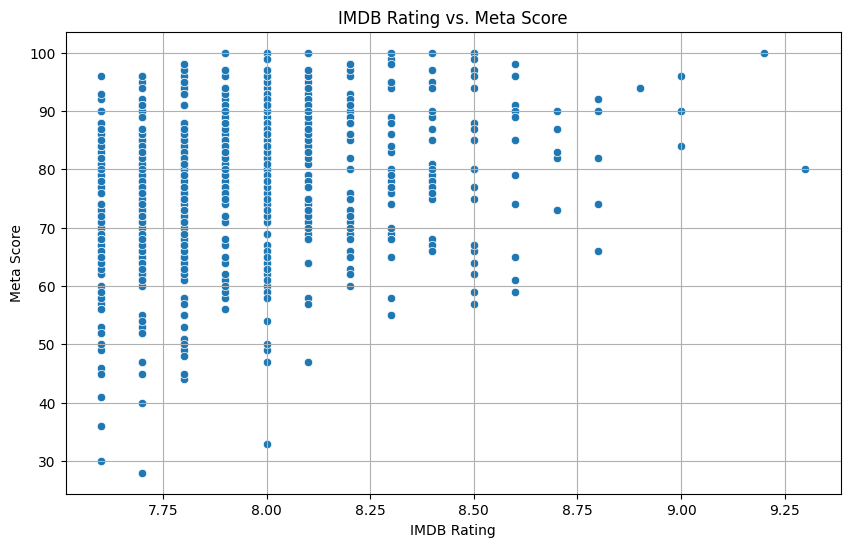

In [17]:
## Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
# In a sentence or two, describe what this pair of scores suggests about the movies.

plt.figure(figsize=(10, 6))
sns.scatterplot(x='IMDB_Rating', y='Meta_score', data=imdb)
plt.title('IMDB Rating vs. Meta Score')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta Score')
plt.grid(True)
plt.show()

# The scatterplot shows the relationship between IDMB Ratings and Meta Scores. There is no real correlation between these two variables.
# There is quite a spread between Meta scores and IDMB Ratings

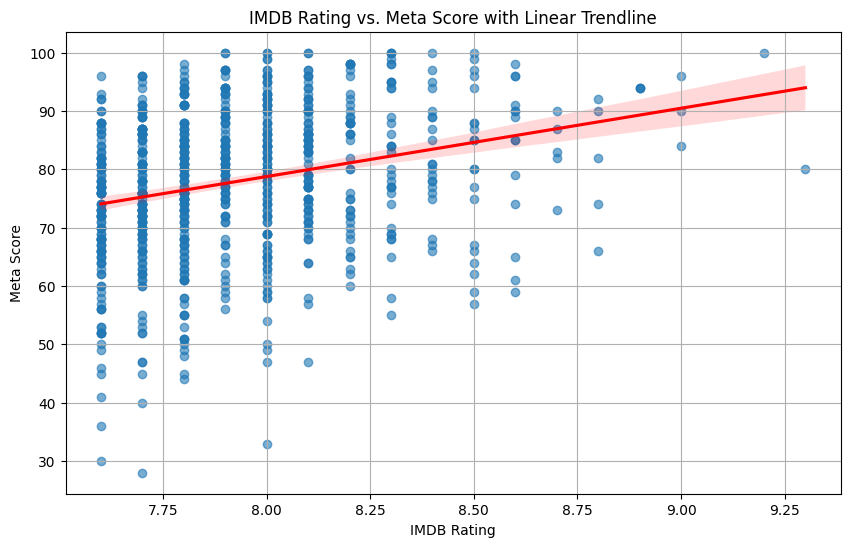

In [18]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.

plt.figure(figsize=(10, 6))
sns.regplot(x='IMDB_Rating', y='Meta_score', data=imdb, scatter_kws={'alpha':0.6}, line_kws={'color':'red'}, order=1)
plt.title('IMDB Rating vs. Meta Score with Linear Trendline')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta Score')
plt.grid(True)
plt.show()



In [19]:
# Do any data points in the scatterplot surprise you?
# Try to identify a few such movies.
#All the movies that are under 40 meta score surpise me, because they fall into the 7.75 rating.
#And there are movies that have a 7.75 rating and are rated 90+.

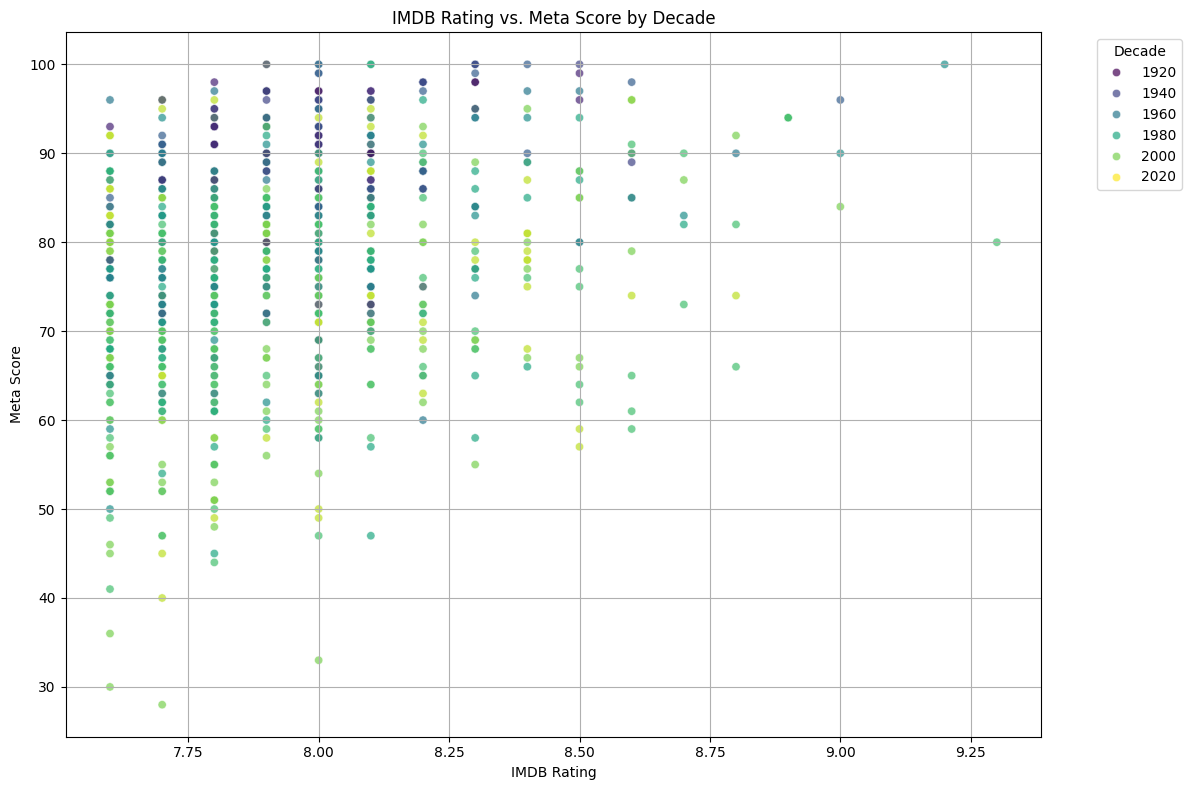

In [20]:
# In the scatterplot, use color to distinguish movies from different decades.
plt.figure(figsize=(12, 8))
sns.scatterplot(x='IMDB_Rating', y='Meta_score', hue='Decade', data=imdb, palette='viridis', alpha=0.7)
plt.title('IMDB Rating vs. Meta Score by Decade')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta Score')
plt.grid(True)
plt.legend(title='Decade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

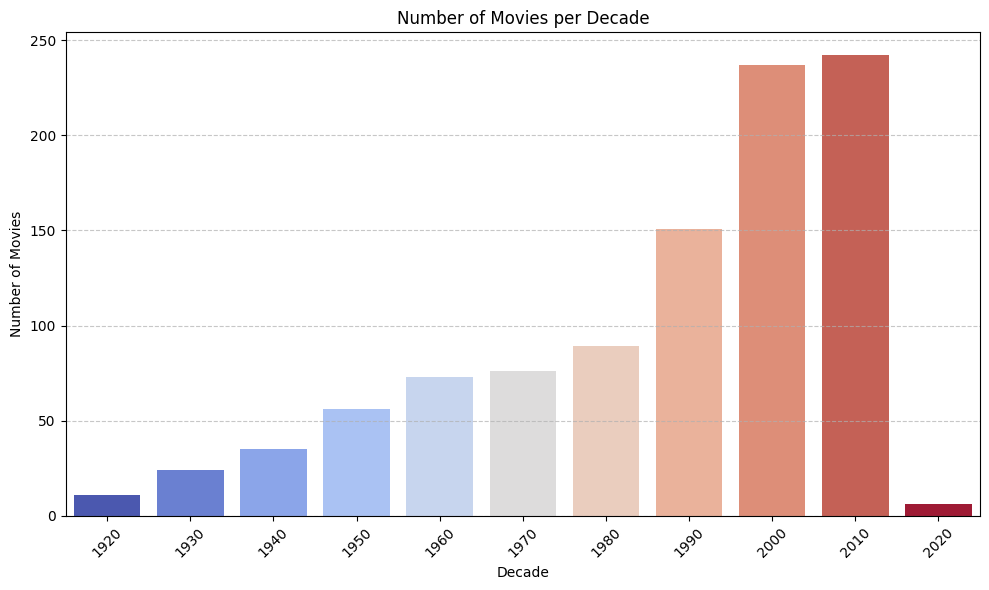

In [21]:
# Create a chart that shows how many movies fall in each decade.
decade_counts = imdb['Decade'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=decade_counts.index, y=decade_counts.values, hue=decade_counts.index, palette='coolwarm', legend=False)
plt.title('Number of Movies per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

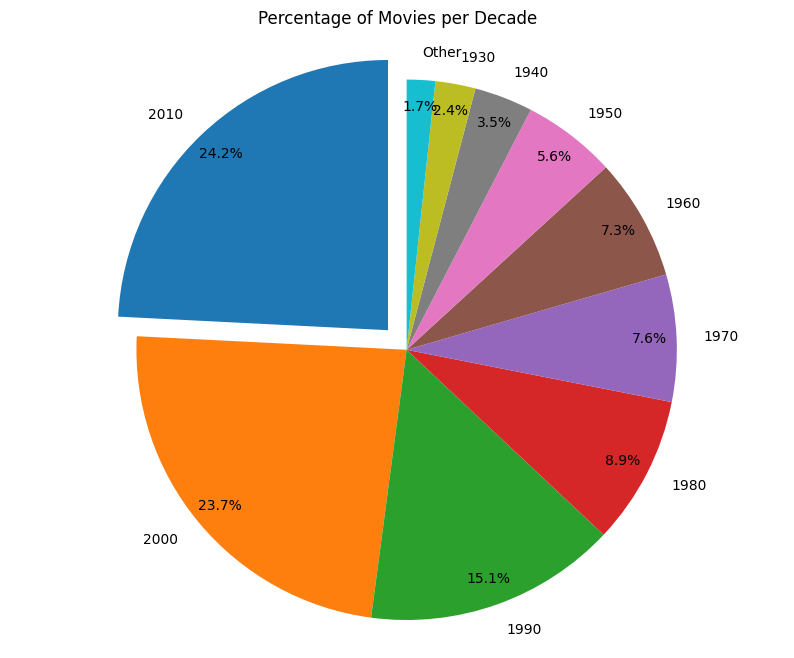

In [22]:


# Create a chart that shows the percentage of movies in each decade.
decade_counts = imdb['Decade'].value_counts().sort_index()
percentage = (decade_counts / decade_counts.sum()) * 100
threshold = 2
other_label = 'Other'
final_percentages = percentage[percentage >= threshold].copy()
other_total = percentage[percentage < threshold].sum()

# other value
if other_total > 0:
    final_percentages.loc[other_label] = other_total

# sort percentages
final_percentages = final_percentages.sort_values(ascending=False)

# exploding the largest slice
explode = [0.1 if label == final_percentages.index[0] else 0 for label in final_percentages.index]

plt.figure(figsize=(10, 8))
plt.pie(final_percentages,
        labels=final_percentages.index,
        autopct='%1.1f%%',
        startangle=90, # Start at the top for better readability
        explode=explode,
        pctdistance= .9 # Distance of percentage labels from the center
       )

plt.title('Percentage of Movies per Decade')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

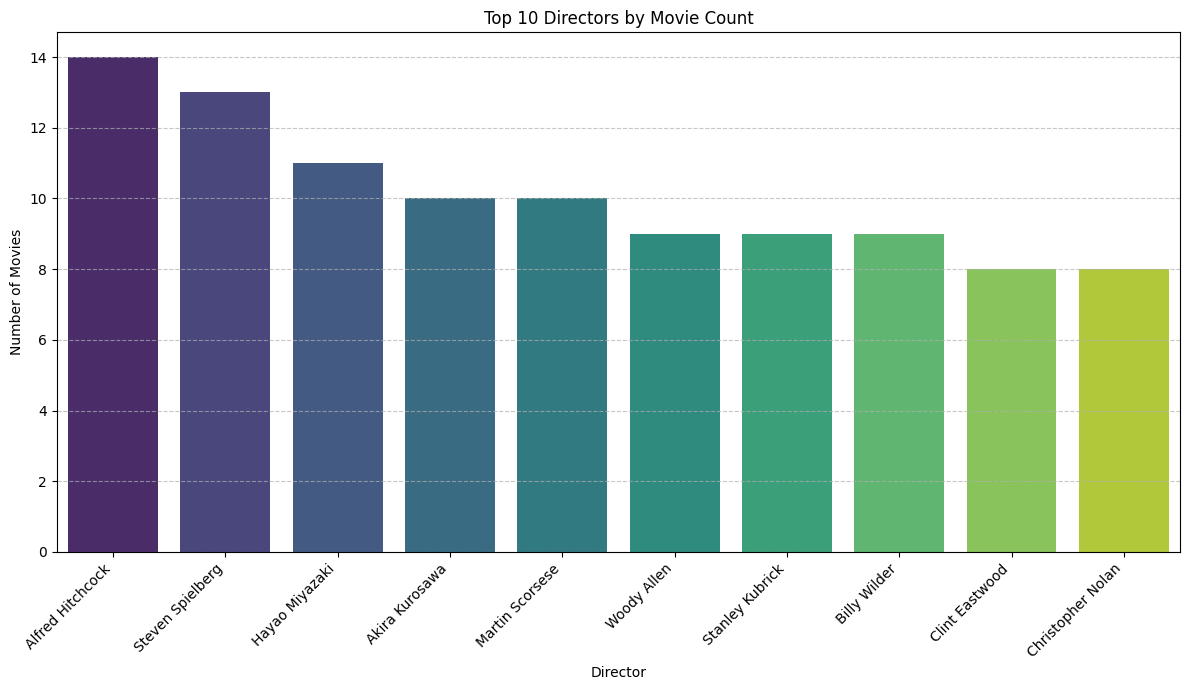

In [23]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.
director_counts = imdb['Director'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=director_counts.index, y=director_counts.values, palette='viridis', hue=director_counts.index, legend=False)
plt.title('Top 10 Directors by Movie Count')
plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

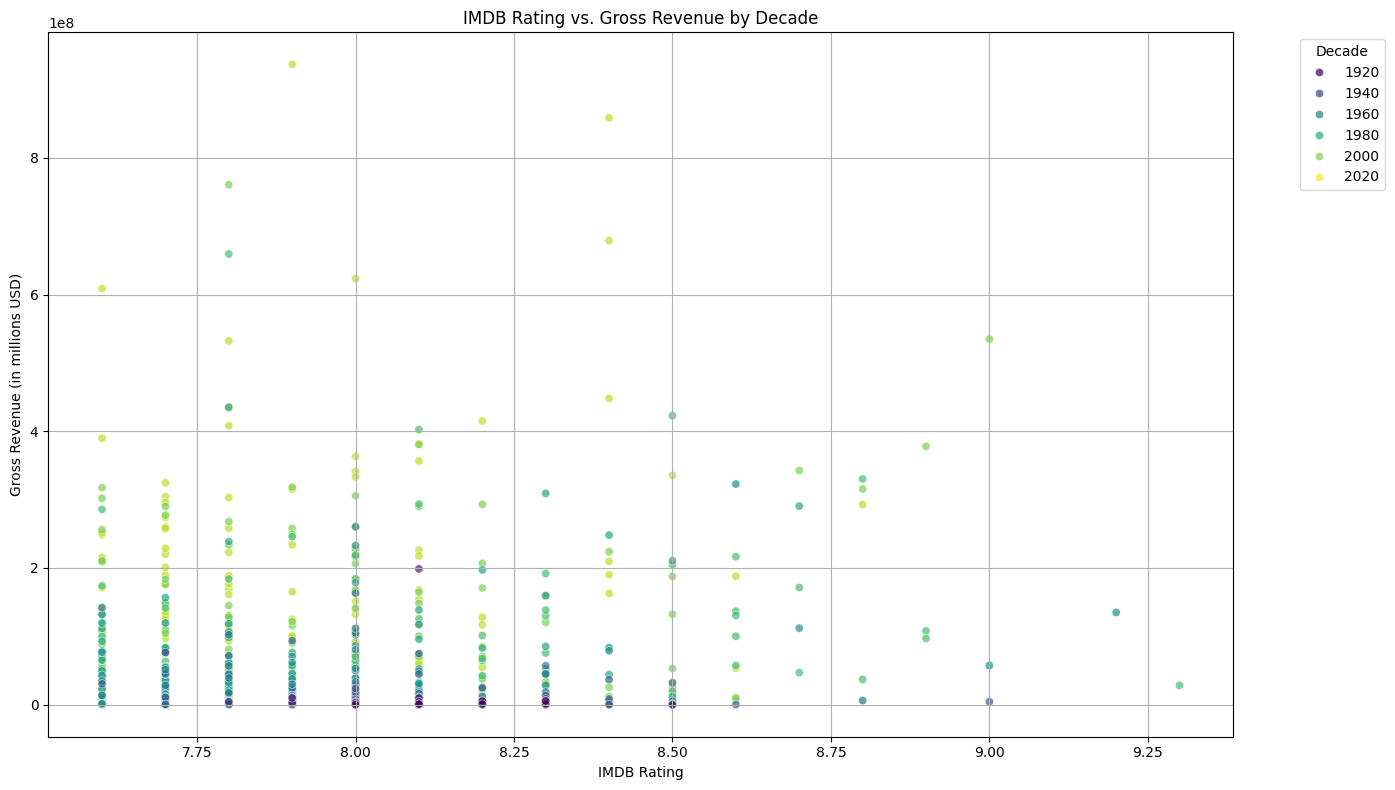

In [24]:
# Create a scatterplot of 'IMDB_Rating' and 'Gross'.
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.

plt.figure(figsize=(14, 8))
sns.scatterplot(x='IMDB_Rating', y='Gross', hue='Decade', data=imdb, palette='viridis', alpha=0.7)
plt.title('IMDB Rating vs. Gross Revenue by Decade')
plt.xlabel('IMDB Rating')
plt.ylabel('Gross Revenue (in millions USD)')
plt.grid(True)
plt.legend(title='Decade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#This show us if higher rated movies make more money

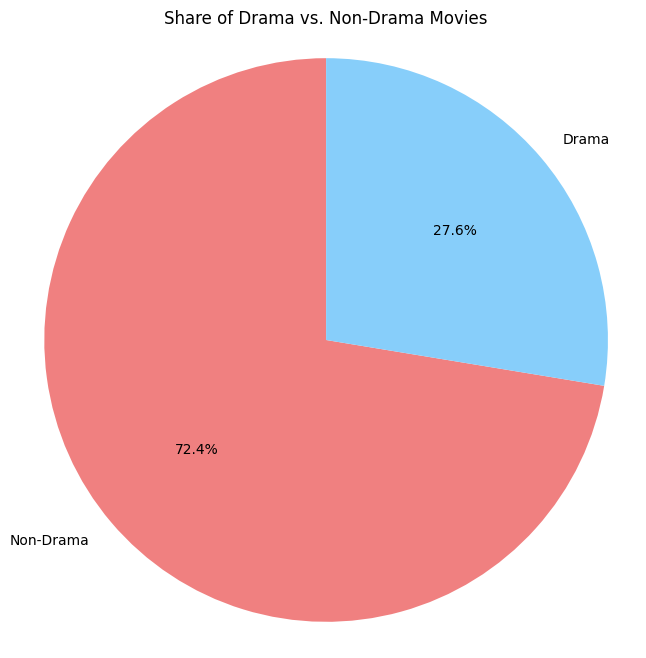

In [25]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
imdb['Drama'] = imdb['Genre'].str.contains('Drama')

# Create a pie chart showing the share of drama vs. non-drama movies.
drama_counts = imdb['Drama'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(drama_counts, labels=['Non-Drama', 'Drama'], autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue'])
plt.title('Share of Drama vs. Non-Drama Movies')
plt.axis('equal')
plt.show()

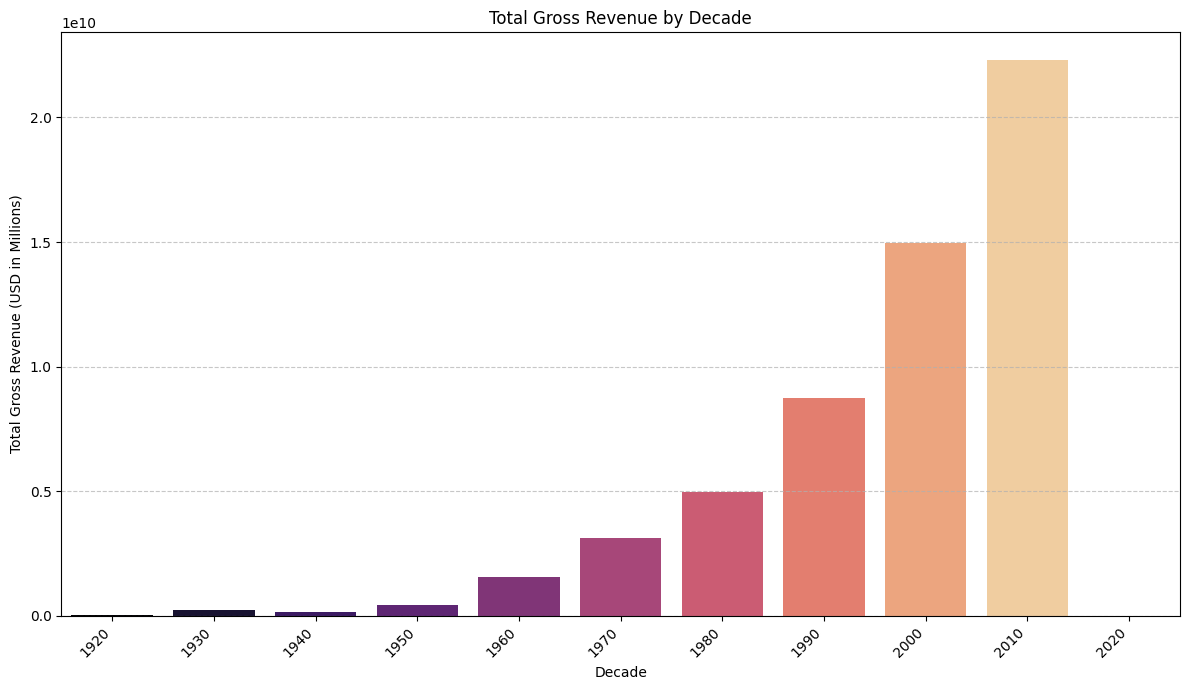

In [26]:
# Create a plot comparing gross revenue across decades.
gross_revenue_by_decade = imdb.groupby('Decade')['Gross'].sum().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Decade', y='Gross', data=gross_revenue_by_decade, palette='magma', hue='Decade', legend=False)
plt.title('Total Gross Revenue by Decade')
plt.xlabel('Decade')
plt.ylabel('Total Gross Revenue (USD in Millions)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

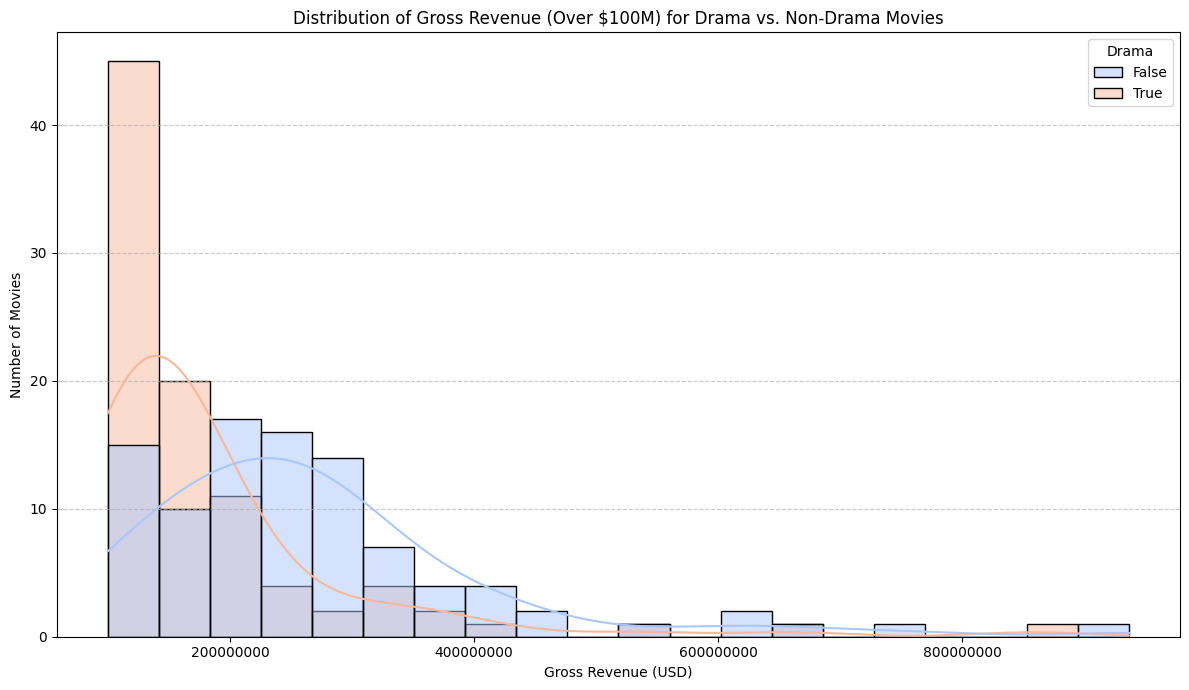

In [27]:
# For movies with gross over $100 million:
# Create a histogram of gross for drama vs. non-drama movies.

movies_over_100M = imdb[imdb['Gross'] > 100000000]

plt.figure(figsize=(12, 7))
sns.histplot(data=movies_over_100M, x='Gross', hue='Drama', kde=True, bins=20, palette='coolwarm')
plt.title('Distribution of Gross Revenue (Over $100M) for Drama vs. Non-Drama Movies')
plt.xlabel('Gross Revenue (USD)')
plt.ylabel('Number of Movies')
plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
# Come up with two more questions about this dataset. Create one chart or figure for each.
# Question 1: Average rating per decade

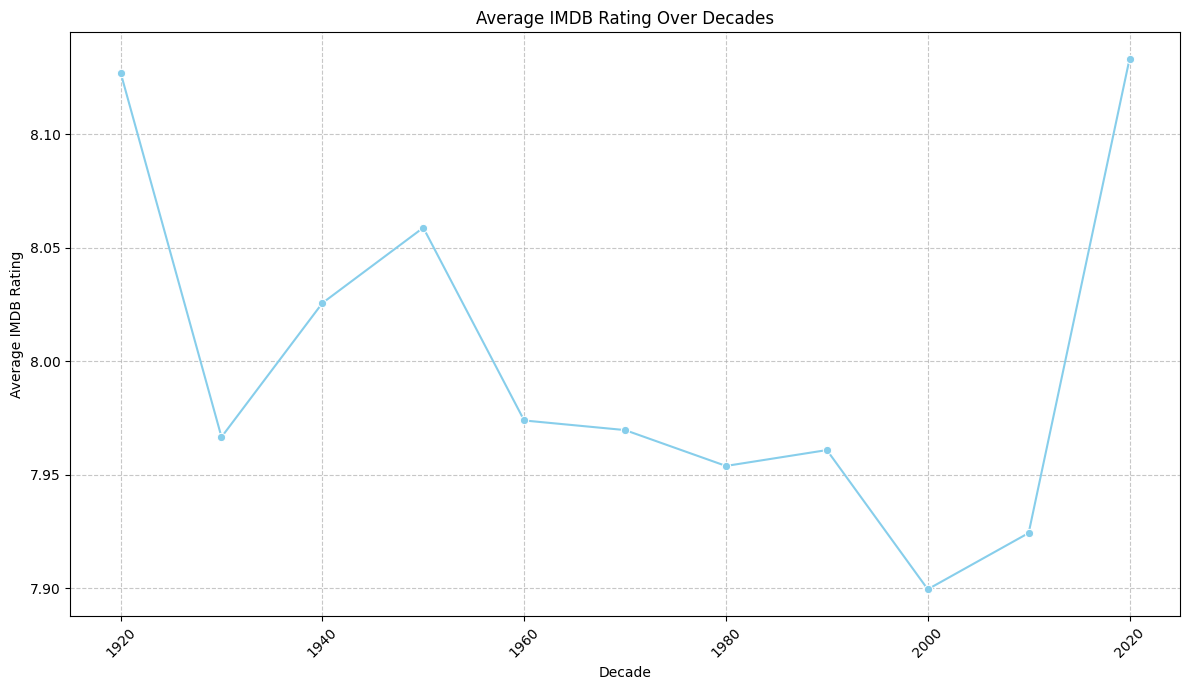

In [29]:
average_rating_by_decade = imdb.groupby('Decade')['IMDB_Rating'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='Decade', y='IMDB_Rating', data=average_rating_by_decade, marker='o', color='skyblue')
plt.title('Average IMDB Rating Over Decades')
plt.xlabel('Decade')
plt.ylabel('Average IMDB Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

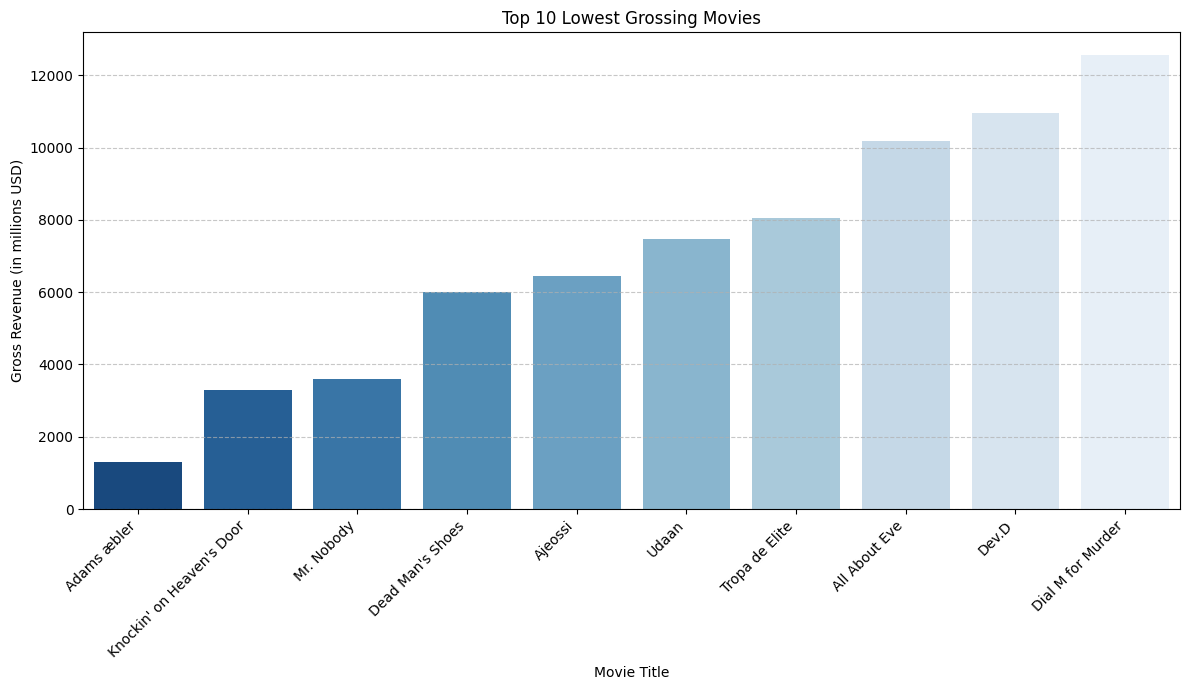

In [30]:
# Question 2:top ten lowest grossing  movies
lowest_grossing_movies = imdb.sort_values(by='Gross', ascending=True).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Series_Title', y='Gross', data=lowest_grossing_movies, palette='Blues_r', hue='Series_Title', legend=False)
plt.title('Top 10 Lowest Grossing Movies')
plt.xlabel('Movie Title')
plt.ylabel('Gross Revenue (in millions USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()